# Breit Rabi solutions

2013_10_23: IBS, Port my MMA solution to the Breit-Rabi equation to python.  
2018_10_17: IBS, Solved for RF dressed states in $F=1$ and $F=2$ at the same field range. 
2025_05_22: IBS, Ported to Julia 

In [91]:
using Pkg
if isfile("Project.toml")
    Pkg.activate(".")
end

Pkg.instantiate()
Pkg.update()
Pkg.resolve()
Pkg.precompile()

  Activating project at `~/Julia/anaysis/BreitRabi Modeling`
Precompiling project...
   2339.6 ms  ✓ QGas
  1 dependency successfully precompiled in 3 seconds. 131 already precompiled.
  1 dependency precompiled but a different version is currently loaded. Restart julia to access the new version. Otherwise, loading dependents of this package may trigger further precompilation to work with the unexpected version.
    Updating registry at `~/.julia/registries/General.toml`
  No Changes to `~/Julia/anaysis/BreitRabi Modeling/Project.toml`
  No Changes to `~/Julia/anaysis/BreitRabi Modeling/Manifest.toml`
  No Changes to `~/Julia/anaysis/BreitRabi Modeling/Project.toml`
  No Changes to `~/Julia/anaysis/BreitRabi Modeling/Manifest.toml`


In [92]:
using LaTeXStrings # Because of the l"" syntax
using Revise
using Printf

import PythonPlot as plt
import PythonCall: pyslice
import LinearAlgebra: Hermitian, eigen

using QGas.AtomicPhysics.BreitRabi: breit_rabi
using QGas.AtomicPhysics.AtomicConstants: ħ, Er_Hz
import QGas.AtomicPhysics.AtomicConstants as AMO

In [93]:
# Some simple example calculations
atom = AMO.Rb87
state = atom.states["5s_1/2"]
;

## Breit Rabi energy computation

Here I will setup the problem of interest.  We can get the $F=1$ and $F=2$ energies here.  Since this started way back when I was a postdoc, and in Mathematica, I hard coded in the matrices rather than using the C-G coefficients and I would do now.

In [94]:


# ──────────────────────────────────────────────────────────────────────
# F = 1  manifold
# ──────────────────────────────────────────────────────────────────────
"""
    rf_coupled_F1(B, freq, Ω)

Return the 3x3 Hermitian Hamiltonian for the *F = 1* manifold.
* `B`     - magnetic field (gauss)  
* `freq`  - RF frequency shift (same units as the Breit-Rabi energies)  
* `Ω`     - RF Rabi frequency
"""
function rf_coupled_F1(B, freq, Ω)
    H = zeros(eltype(B + freq + Ω), 3, 3)

    H[1, 1] = breit_rabi(B, -1, -1, state) - freq
    H[2, 2] = breit_rabi(B,  0, -1, state)
    H[3, 3] = breit_rabi(B, +1, -1, state) + freq

    off = Ω / √2
    H[1, 2] = H[2, 1] = off
    H[2, 3] = H[3, 2] = off

    return Hermitian(H)               # ensures symmetry for eigensolver
end

"""
    rf_coupled_energies_F1(B, freq, Ω)

Eigen-energies of the F = 1 RF-coupled Hamiltonian.
"""
rf_coupled_energies_F1(B, freq, Ω) = eigen(rf_coupled_F1(B, freq, Ω)).values
rf_coupled_energies_F1(B, freq, Ω, n) = rf_coupled_energies_F1(B, freq, Ω)[n]


# ──────────────────────────────────────────────────────────────────────
# F = 2  manifold
# ──────────────────────────────────────────────────────────────────────
function rf_coupled_F2(B, freq, Ω)
    H = zeros(eltype(B + freq + Ω), 5, 5)

    H[1, 1] = breit_rabi(B, -2, 1, state) + 2freq
    H[2, 2] = breit_rabi(B, -1, 1, state) + freq
    H[3, 3] = breit_rabi(B,  0, 1, state)
    H[4, 4] = breit_rabi(B, +1, 1, state) - freq
    H[5, 5] = breit_rabi(B, +2, 1, state) - 2freq

    H[1, 2] = H[2, 1] = Ω
    s = Ω * √6 / 2
    H[2, 3] = H[3, 2] = s
    H[3, 4] = H[4, 3] = s
    H[4, 5] = H[5, 4] = Ω

    return Hermitian(H)
end

rf_coupled_energies_F2(B, freq, Ω) = eigen(rf_coupled_F2(B, freq, Ω)).values
rf_coupled_energies_F2(B, freq, Ω, n) = rf_coupled_energies_F2(B, freq, Ω)[n]

rf_coupled_energies_F2 (generic function with 2 methods)

In [95]:
display(rf_coupled_F2(0, 0, 1.0))
display(rf_coupled_energies_F2(0, 0, 1.0))

5×5 Hermitian{Float64, Matrix{Float64}}:
 2.56301e9  1.0        0.0        0.0        0.0
 1.0        2.56301e9  1.22474    0.0        0.0
 0.0        1.22474    2.56301e9  1.22474    0.0
 0.0        0.0        1.22474    2.56301e9  1.0
 0.0        0.0        0.0        1.0        2.56301e9

5-element Vector{Float64}:
 2.563005977089109e9
 2.563005978089109e9
 2.563005979089109e9
 2.563005980089109e9
 2.563005981089109e9

## Examples for $^{87}{\rm Rb}$

This space is a combination of demonstration and quick calculations.

In [96]:
# Typical Parameters
B = 2
freq = 0
Ω_RF = 0


Δν = (breit_rabi(B, 2, 1, state) - breit_rabi(B, 1, -1, state)) / 1e6
msg = @sprintf "Model B = %g G: %.3f MHz" B Δν
println(msg)
println( "Reality: ", 6934.683-(59+17.54)) 

Model B = 2 G: 6838.887 MHz
Reality: 6858.143


In [97]:
# Typical Parameters
B = 25;
freq = 0;
Ω_RF = 3;

# solve the matrix for many B values and plot energies
domain = range(0.0, stop=30.0, length=128)

energies_0 = rf_coupled_energies_F1.(domain, freq, Ω_RF, 1);
energies_0 .-= rf_coupled_energies_F1(0.0, freq, Ω_RF, 1);
energies_1 = rf_coupled_energies_F1.(domain, freq, Ω_RF, 2);
energies_1 .-= rf_coupled_energies_F1(0.0, freq, Ω_RF, 2);
energies_2 = rf_coupled_energies_F1.(domain, freq, Ω_RF, 3);
energies_2 .-= rf_coupled_energies_F1(0.0, freq, Ω_RF, 3);

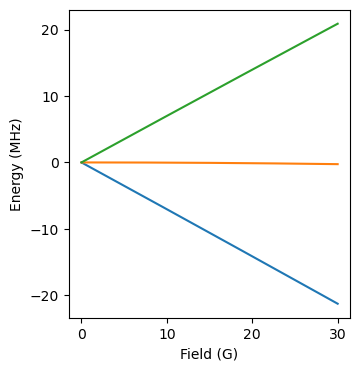

In [ ]:
fig = plt.figure(figsize=(8,4));
ax1=fig.add_subplot(121);
ax1.plot(domain,energies_0 / 1e6,"-",domain,energies_1 / 1e6,"-",domain,energies_2 / 1e6,"-")
ax1.set_xlabel("Field (G)")
ax1.set_ylabel("Energy (MHz)")
fig.savefig("energies.pdf")
display(fig)

Now look at the quadratic Zeeman shift in $F=1$

In [99]:
# Typical Parameters
B = 1.4239
freq = 0.0
Ω_RF = 0.0
λ = 790e-9

# Need to reverse because of the order that eigen yields.
energies = rf_coupled_energies_F1(B, freq, Ω_RF)
energies .-= rf_coupled_energies_F1(0, freq, Ω_RF, 1)

shift = (energies[1] - energies[3])/2.0
linear_energies = shift .* [1,0,-1]
q_shift = energies - linear_energies

println(energies)
println("Linear Zeeman shift in Hz:", shift)
println("Quad in Hz", q_shift .- q_shift[2])
println("Quad Er",  (q_shift .- q_shift[2])./Er_Hz(atom, λ) )

[-1.000540359038353e6, -583.051718711853, 999665.7813668251]
Linear Zeeman shift in Hz:-1.000103070202589e6
Quad in Hz[145.76288294792175, 0.0, 145.76288294792175]
Quad Er[0.039626877327819984, 0.0, 0.039626877327819984]


Now look at the quadratic Zeeman shift in $F=2$

In [100]:
energies = rf_coupled_energies_F2(B, freq, Ω_RF)
energies .-= rf_coupled_energies_F2(0, freq, Ω_RF,1);
println(energies)

shift = (energies[1] - energies[5])/4.0

println("Linear Zeeman shift in Hz:", shift)
linear_energies = shift .* [2,1,0,-1,-2]
println("Quad shifts")
q_shift = energies .- linear_energies

println(q_shift .- q_shift[3])

[-1.9922734255356789e6, -995699.2962117195, 583.051718711853, 996573.8738822937, 1.992273425535202e6]
Linear Zeeman shift in Hz:-996136.7127677202
Quad shifts
[-583.0517189502716, -145.6351627111435, 0.0, -145.89060413837433, -583.0517189502716]


Quadradic Zeeman shift for high-field three state experiment

In [101]:
# Typical Parameters
B = 25.56359; # was 25.5605
freq = 0.0;
Ω_RF = 0.0;
λ = 790.024e-9;
Er = Er_Hz(atom, λ);

println("Some frequencies measured in the lab; shifting another 4 Er to account for kinetic energy");
println("Er = ", Er);
println(89 - (71.109-4*Er*1e-6) );
println(89 - (70.987+4*Er*1e-6) );

energies = [breit_rabi(B, mf, -1, state) for mf in 1:-1:-1]
energies .-= breit_rabi(B, 0, -1, state)

println("DeltaE(1,0) = ", energies[2]-energies[1])
println("DeltaE(0,-1) = ", energies[3]-energies[2])
println("Quad = ", (energies[1] + energies[3]) - 2.0*energies[2])
println("EpsilonQuad = ", (energies[1] + energies[3])/2.0 - energies[2])
println("EpsilonQuad/Er = ", ((energies[1] + energies[3])/2.0 - energies[2])/Er)

Some frequencies measured in the lab; shifting another 4 Er to account for kinetic energy
Er = 3678.160801487163
17.90571264320596
17.99828735679405
DeltaE(1,0) = 1.7907357812446594e7
DeltaE(0,-1) = 1.8001309612941742e7
Quad = 93951.8004951477
EpsilonQuad = 46975.90024757385
EpsilonQuad/Er = 12.77157328972144


In [102]:
# Typical Parameters
B = 35.46912; # was 25.5605
freq = 0.0;
Ω_RF = 0.0;
λ = 790.024e-9;
Er = Er_Hz(atom, λ);

energies = [breit_rabi(B, mf, -1, state) for mf in 1:-1:-1]
energies .-= breit_rabi(B, 0, -1, state)

println("DeltaE(1,0) = ", energies[2]-energies[1])
println("DeltaE(0,-1) = ", energies[3]-energies[2])
println("Quad = ", (energies[1] + energies[3]) - 2.0*energies[2])
println("EpsilonQuad = ", (energies[1] + energies[3])/2.0 - energies[2])
println("EpsilonQuad/Er = ", ((energies[1] + energies[3])/2.0 - energies[2])/Er)

DeltaE(1,0) = 2.4820012638421535e7
DeltaE(0,-1) = 2.5000859000336647e7
Quad = 180846.36191511154
EpsilonQuad = 90423.18095755577
EpsilonQuad/Er = 24.583803111869294


## Reduced model parameters

The basic idea of this section is to use the Breit Rabi equation to find as a function of $B$:

1. The difference in resonance condition between $F=1$ and $F=2$ (defined as the frequency where the largest $|m_F|$ states are degenerate).
2. The quadratic Zeeman shift.

I will define my model such that $F=1$ is the reference and we measure how different $F=2$ is from $F=1$.

... add additional notes here as I progress ...

remember that in the reduced model, the sign of the overall detuning is off by -1 between $F=1$ and $F=2$.

In [142]:
function reduced_mode_parameters(B; debug=true)
    # get the energies [currently subtracting the m_F = 0 energies]
    energies_F1 = [breit_rabi(B, mf, -1, state) for mf in -1:1]; energies_F1 .-= energies_F1[2];
    energies_F2 = [breit_rabi(B, mf, +1, state) for mf in -2:2]; energies_F2 .-= energies_F2[3]

    # Compute the linear Zeeman shifts (notice that the order is reversed because of the opposite magnetic moment)
    linear_F1 = (energies_F1[1] - energies_F1[3])/2.0
    linear_F2 = (energies_F2[5] - energies_F2[1])/4.0

    # Subtract the linear shifts and obtain quadratic shits:
    energies_F1 .+= linear_F1 .* Vector(-1:1)
    energies_F2 .-= linear_F2 .* Vector(-2:2)

    quad_F1 = (energies_F1[1] + energies_F1[3])/2.0
    quad_F2 = (energies_F2[1] + energies_F2[5])/8.0

    # Subtract the quad shift to see residuals
    energies_F1 .-= quad_F1 .* Vector(-1:1).^2
    energies_F2 .-= quad_F2 .* Vector(-2:2).^2

    if debug
        println("F=1 residuals in Hz = ", energies_F1)
        println("F=2 residuals in Hz = ", energies_F2)
    end

    (
        linear_F1=linear_F1, 
        linear_F2=linear_F2,
        linear_Δ_21=linear_F2-linear_F1,
        quad_F1=quad_F1,
        quad_F2=quad_F2,
        quad_Δ_21=quad_F1 + quad_F2)
end

display(reduced_mode_parameters(1.0))

display(reduced_mode_parameters(10.0))

(linear_F1 = 702368.9408864975, linear_F2 = 699583.3364474773, linear_Δ_21 = -2785.604439020157, quad_F1 = 71.89323997497559, quad_F2 = -71.89325165748596, quad_Δ_21 = -1.1682510375976562e-5)

(linear_F1 = 7.023645610575914e6, linear_F2 = 6.995833364475131e6, linear_Δ_21 = -27812.246100783348, quad_F1 = 7189.181790590286, quad_F2 = -7189.2952244877815, quad_Δ_21 = -0.11343389749526978)

F=1 residuals in Hz = [0.0, 0.0, 0.0]
F=2 residuals in Hz = [0.0, 0.04425239562988281, 0.0, -0.044229984283447266, 0.0]
F=1 residuals in Hz = [0.0, 0.0, 0.0]
F=2 residuals in Hz = [0.0, 44.35413616895676, 0.0, -44.12726837396622, 0.0]


So we see that at 1 Hz this model works VERY well, but at 10 G there is an additional cubic term that matters a lot in $F=2$.  This would motivate me to change my definitions slightly, but I am not going to worry about this.  

But even at 10 G the quadratic shifts differ only by 0.1 Hz, where as the linear shifts differ by $-27 kHz$!

### Reduced parameters example

The next step is to make a plot of the parameters resulting from this to generate a model that links them all together.  We see that these are well represented by linear / quadratic functions so I will easily pick off model coefficients.

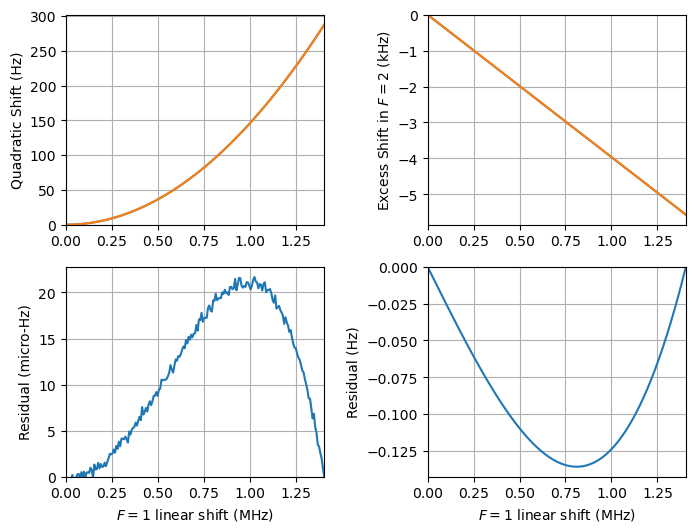

Quad coefficient, Q_coef = 145.73281870988927 Hz / MHz^2
Linear coefficient, L_coef = -3965.8249116500883 Hz / MHz


In [193]:
fields = collect(0.0:0.01:2.0)
reduced = reduced_mode_parameters.(fields; debug=false)

quad_F1s = [r.quad_F1 for r in reduced]
linear_F1 = [r.linear_F1 for r in reduced]
linear_Δs = [r.linear_Δ_21 for r in reduced]

# Derive an approximate quadratic model for the quad shift (as a function of the F=1 resonant RF frequency)
quad_coef = quad_F1s[end] / (linear_F1[end])^2
println("Quad coefficient, Q_coef = ", quad_coef .*1e12, " Hz / MHz^2")

# And linear for the linear case
linear_coef = linear_Δs[end] / linear_F1[end]
println("Linear coefficient, L_coef = ", linear_coef .* 1e6, " Hz / MHz")


# Quad, including residuals
fig = plt.figure(figsize=(8,6));
gs  = fig.add_gridspec(2, 2; wspace = 0.4)   # wspace: column gap

xlim = [0,linear_F1[end] ./ 1e6]

ax=fig.add_subplot(gs[0,0]);
ax.plot(linear_F1 ./ 1e6, quad_F1s, "-")
ax.plot(linear_F1 ./ 1e6, quad_coef .* linear_F1.^2, "-")
ax.set_ylabel("Quadratic Shift (Hz)")
ax.grid(true)
ax.set_xlim(xlim...)
ax.set_ylim(0, nothing)

ax=fig.add_subplot(gs[1,0]);
ax.plot(linear_F1 ./ 1e6, (quad_F1s - quad_coef .* linear_F1.^2).*1e6, "-")
ax.set_xlabel(L"$F=1$ linear shift (MHz)")
ax.set_ylabel("Residual (micro-Hz)")
ax.grid(true)
ax.set_xlim(xlim...)
ax.set_ylim(0, nothing)


# Linear, including residuals
ax=fig.add_subplot(gs[0,1]);
ax.plot(linear_F1 ./ 1e6, linear_Δs./ 1e3, "-")
ax.plot(linear_F1 ./ 1e6, linear_coef .* linear_F1./ 1e3, "-")
ax.set_ylabel(L"Excess Shift in $F=2$ (kHz)")
ax.grid(true)
ax.set_xlim(xlim...)
ax.set_ylim(nothing, 0)

ax=fig.add_subplot(gs[1,1]);
ax.plot(linear_F1 ./ 1e6, linear_Δs - linear_coef .* linear_F1, "-")
ax.set_xlabel(L"$F=1$ linear shift (MHz)")
ax.set_ylabel("Residual (Hz)")
ax.grid(true)
ax.set_xlim(xlim...)
ax.set_ylim(nothing, 0)

fig.savefig("Reduced.pdf")
display(fig)

This is therefore saying that we should use the following model:
$$
H = \left\{\delta \hat F_z^{(1)} + \Omega F_z^{(1)} + \epsilon_Q(B) [\hat F_z^{(1)}]^2\right\}  - \left\{[\delta - \delta_{21}(B)] F_z^{(2)} + \epsilon_Q(B) (\hat F_z^{(2)})^2 + \Omega F_z^{(2)}\right\} + \left\{\Delta_\mu \hat I^{(1)} + \Omega_\mu H^{(12)}\right\}.
$$
with
\begin{align}
\Delta_{21}(B) &= L_{\rm coef} B & {\rm and} && \delta_{21}(B) &= Q_{\rm coef} B^2
\end{align}

I am not fully sure that I got the sign on $\Delta_{21}(B)$ correct (I am pretty sure).  So the next step would just be to plot the predictions of this, say at 1 MHz vs the Breit-Rabi to make sure.  Also note that by $B$ above I really mean the $F=1$ linear Zeeman shift.

# The following code has NOT been ported to Julia!

## Rf coupled states in $^{87}{\rm Rb}$

166484.7755060196 249753.11455249786 -83268.33904647827
-1.9993766828120831 -2.999376682812083 1


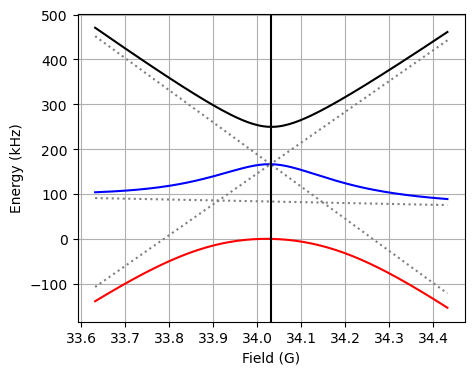

In [ ]:
#
#
# fzx0: 207667.816965 
# fzy0: 332098.687514

# Typical Parameters (for finding 1:2:3 ratio)
B = 34.032
freq = 23.9e6
Ω_RF = 117727
E0 = rf_coupled_energies_F1(B, freq, Ω_RF, 0)

DeltaESmall = rf_coupled_energies_F1(B, freq, Ω_RF, 1) - rf_coupled_energies_F1(B, freq, Ω_RF, 2)
# Print the proposed resonance energy differences
println(
    rf_coupled_energies_F1(B, freq, Ω_RF, 1)-E0, 
    rf_coupled_energies_F1(B, freq, Ω_RF, 2)-E0,
    rf_coupled_energies_F1(B, freq, Ω_RF, 1) - rf_coupled_energies_F1(B, freq, Ω_RF, 2) )

# Fractions
println(
    (rf_coupled_energies_F1(B, freq, Ω_RF, 1)-E0) /DeltaESmall , 
    (rf_coupled_energies_F1(B, freq, Ω_RF, 2)-E0) / DeltaESmall,
    1 )


# solve the matrix for many B values and plot energies

domain = range(B-0.4, stop=B+0.4, length=128)

energies_0 = [vrf_coupled_energies_F1(domain, freq, Ω_RF*0, state) - E0 for state in range(3)]
energiesRF = [vrf_coupled_energies_F1(domain, freq, Ω_RF, state) - E0 for state in range(3)]

plt.figure(1,figsize=(5,4));
ax1=plt.subplot(111)

colors = ['red', 'blue', 'black', 'green', 'orange']
for state in range(3):   
    c = colors[state]
    ax1.plot(domain, energies_0[state] / 1e3,":", color='grey')
    ax1.plot(domain, energiesRF[state] / 1e3,"-", color=c)

ax1.axvline(B, color='k')
ax1.set_xlabel('Field (G)')
ax1.set_ylabel('Energy (kHz)')
ax1.grid(True)
plt.savefig("energies.pdf")


# Look the energies in F=2

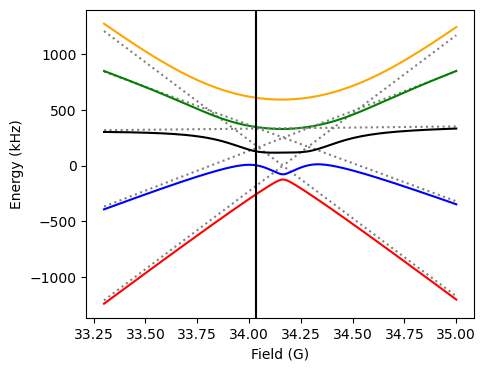

In [ ]:
# Typical Parameters
B = 34.032
freq = 23.9e6
Ω_RF = 160e3

# solve the matrix for many B values and plot energies
E0 = rf_coupled_energies_F2(0, freq, Ω_RF, 2)
domain = range(33.3, stop=35, length=128)


energies_0 = [vrf_coupled_energies_F2(domain, freq, Ω_RF*0, state) - E0 for state in range(5)]
energiesRF = [vrf_coupled_energies_F2(domain, freq, Ω_RF, state) - E0 for state in range(5)]

plt.figure(1,figsize=(5,4));
ax1=plt.subplot(111)

colors = ['red', 'blue', 'black', 'green', 'orange']
for state in range(5):   
    c = colors[state]
    ax1.plot(domain, energies_0[state] / 1e3,":", color='grey')
    ax1.plot(domain, energiesRF[state] / 1e3,"-", color=c)

ax1.axvline(B, color='k')
ax1.set_xlabel('Field (G)')
ax1.set_ylabel('Energy (kHz)')
plt.savefig("energies.pdf")

# $F=1$ to $F=2$ dressed state energy differences

Here I am looking at the set of all energy differences as a function of magnetic field and detuning between these two manifolds.

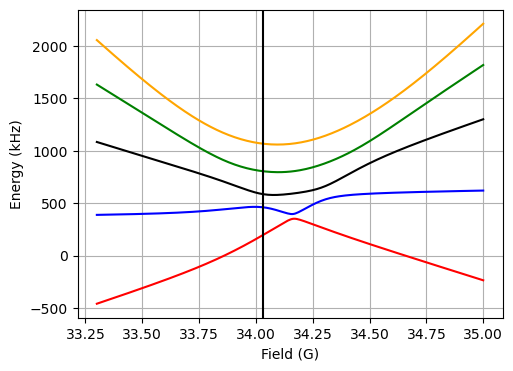

In [ ]:
# Parameters
B = 34.032
freq = 23.9e6
Ω_RF = 160e3

# Compute the F=1 and F=2 energies as a function of magnetic field
domain = range(33.3, stop=35, length=128)

E0_F1 = rf_coupled_energies_F1(0, freq, Ω_RF, 1)

energies_0_F1 = [vrf_coupled_energies_F1(domain, freq, Ω_RF*0, state) - E0_F1 for state in range(3)]
energiesRF_F1 = [vrf_coupled_energies_F1(domain, freq, Ω_RF, state) - E0_F1 for state in range(3)]

# Make denominator the 700 kHz gauss number from F=1
D_energiesRF_F1 = np.diff(energiesRF_F1, axis=1) / (700e3*(domain[1] - domain[0]))

E0_F2 = rf_coupled_energies_F2(0, freq, Ω_RF, 2)
energies_0_F2 = [vrf_coupled_energies_F2(domain, freq, Ω_RF*0, state) - E0_F2 for state in range(5)]
energiesRF_F2 = [vrf_coupled_energies_F2(domain, freq, Ω_RF, state) - E0_F2 for state in range(5)]
D_energiesRF_F2 = np.diff(energiesRF_F2, axis=1) / (700e3*(domain[1] - domain[0]))

fig = plt.figure(1,figsize=(5,4));
gs = gridspec.GridSpec(1, 1)
gs.update(left=0.1, right=0.95, top=0.92, bottom = 0.15, hspace=0.7, wspace = 0.6)

colors = ['red', 'blue', 'black', 'green', 'orange']

ax1=fig.add_subplot(gs[0,0])
state_F1 = 0
for state_F2 in range(5):   
    c = colors[state_F2]
    ax1.plot(domain, (energiesRF_F2[state_F2] - energiesRF_F1[state_F1]) / 1e3, "-", color=c)

ax1.axvline(B, color='k')
ax1.set_xlabel('Field (G)')
ax1.set_ylabel('Energy (kHz)')
ax1.grid(True)

In [ ]:
# Now add in the energy sensitivity

1.7983253984740126
-0.3666004446850432
-0.48338521466980344
-0.36789205671071407
-0.35069700273818166


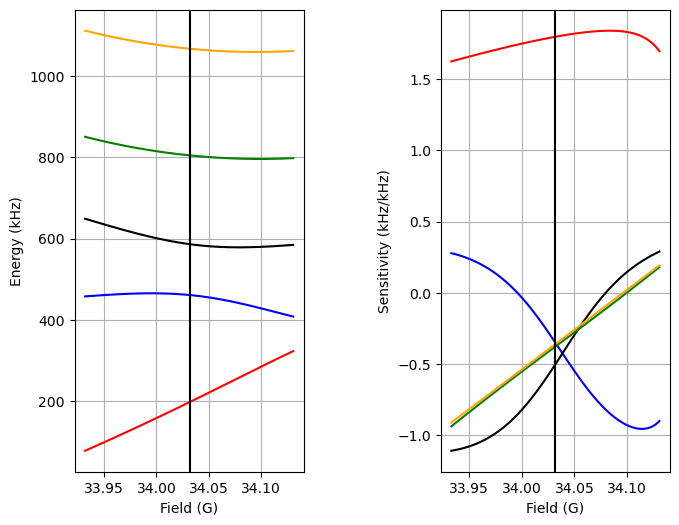

In [ ]:
# Parameters
B = 34.032
freq = 23.9e6
Ω_RF = 160e3

# Compute the F=1 and F=2 energies as a function of magnetic field
domain = range(B-0.1, stop=B+0.1, length=128)

E0_F1 = rf_coupled_energies_F1(0, freq, Ω_RF, 1)

energies_0_F1 = [vrf_coupled_energies_F1(domain, freq, Ω_RF*0, state) - E0_F1 for state in range(3)]
energiesRF_F1 = [vrf_coupled_energies_F1(domain, freq, Ω_RF, state) - E0_F1 for state in range(3)]

# Make denominator the 700 kHz gauss number from F=1
D_energiesRF_F1 = np.diff(energiesRF_F1, axis=1) / (700e3*(domain[1] - domain[0]))

E0_F2 = rf_coupled_energies_F2(0, freq, Ω_RF, 2)
energies_0_F2 = [vrf_coupled_energies_F2(domain, freq, Ω_RF*0, state) - E0_F2 for state in range(5)]
energiesRF_F2 = [vrf_coupled_energies_F2(domain, freq, Ω_RF, state) - E0_F2 for state in range(5)]
D_energiesRF_F2 = np.diff(energiesRF_F2, axis=1) / (700e3*(domain[1] - domain[0]))

state_F1 = 0; 
for state_F2 in range(5):   
    println(D_energiesRF_F2[state_F2][64] - D_energiesRF_F1[state_F1][64])

fig = plt.figure(1,figsize=(7,6));
gs = gridspec.GridSpec(1, 2)
gs.update(left=0.1, right=0.95, top=0.92, bottom = 0.15, hspace=0.7, wspace = 0.6)

colors = ['red', 'blue', 'black', 'green', 'orange']

ax1=fig.add_subplot(gs[0,0])
state_F1 = 0
for state_F2 in range(5):   
    c = colors[state_F2]
    ax1.plot(domain, (energiesRF_F2[state_F2] - energiesRF_F1[state_F1]) / 1e3, "-", color=c)

ax1.axvline(B, color='k')
ax1.set_xlabel('Field (G)')
ax1.set_ylabel('Energy (kHz)')
ax1.grid(True)

ax1=fig.add_subplot(gs[0,1])
state_F1 = 0
for state_F2 in range(5):   
    c = colors[state_F2]
    ax1.plot(domain[1:], (D_energiesRF_F2[state_F2] - D_energiesRF_F1[state_F1]), "-", color=c)

ax1.axvline(B, color='k')
ax1.set_xlabel('Field (G)')
ax1.set_ylabel('Sensitivity (kHz/kHz)')
ax1.grid(True)

0.03853767578899858
-0.45518398138582705
0.719604055672884
1.6911987200826406
2.8435307176917792


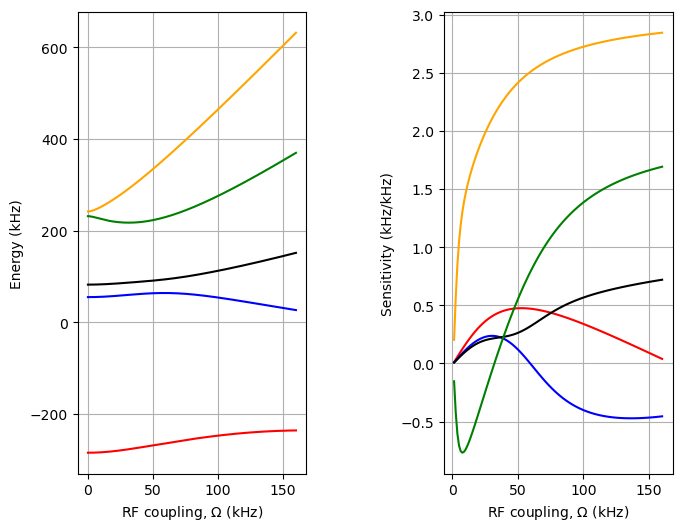

In [ ]:
# Parameters
B = 34.032
freq = 23.9e6
Ω_RF = 160e3

# Compute the F=1 and F=2 energies as a function of magnetic field
domain = range(0, stop=Ω_RF, length=128)


E0_F1 = rf_coupled_energies_F1(B, freq, 0, 1)
energiesRF_F1 = [vrf_coupled_energies_F1(B, freq, domain, state) - E0_F1 for state in range(3)]
D_energiesRF_F1 = np.diff(energiesRF_F1, axis=1) / (domain[1] - domain[0])

E0_F2 = rf_coupled_energies_F2(B, freq, 0, 2)
energiesRF_F2 = [vrf_coupled_energies_F2(B, freq, domain, state) - E0_F2 for state in range(5)]
D_energiesRF_F2 = np.diff(energiesRF_F2, axis=1) / (domain[1] - domain[0])

state_F1 = 0; 
for state_F2 in range(5):   
    println(D_energiesRF_F2[state_F2][-1] - D_energiesRF_F1[state_F1][-1])


fig = plt.figure(1,figsize=(7,6));
gs = gridspec.GridSpec(1, 2)
gs.update(left=0.1, right=0.95, top=0.92, bottom = 0.15, hspace=0.7, wspace = 0.6)

colors = ['red', 'blue', 'black', 'green', 'orange']

ax1=fig.add_subplot(gs[0,0])
state_F1 = 0
for state_F2 in range(5):   
    c = colors[state_F2]
    ax1.plot(domain/ 1e3, (energiesRF_F2[state_F2] - energiesRF_F1[state_F1]) / 1e3, "-", color=c)

# ax1.axvline(165, color='k')
ax1.set_xlabel('RF coupling, $\Omega$ (kHz)')
ax1.set_ylabel('Energy (kHz)')
ax1.grid(True)

ax1=fig.add_subplot(gs[0,1])
state_F1 = 0
for state_F2 in range(5):   
    c = colors[state_F2]
    ax1.plot(domain[1:] / 1e3, (D_energiesRF_F2[state_F2] - D_energiesRF_F1[state_F1]), "-", color=c)

# ax1.axvline(165, color='k')
ax1.set_xlabel('RF coupling, $\Omega$ (kHz)')
ax1.set_ylabel('Sensitivity (kHz/kHz)')
ax1.grid(True)

In [ ]:
state_F1 = 0; 
for state_F2 in range(5):   
    println(D_energiesRF_F2[state_F2][64] - D_energiesRF_F1[state_F1][64])

0.41257627559304233
-0.27682242939174184
0.4776366886138916
1.1854523653775453
2.651331439146399


In [ ]:
D_energiesRF_F1[:,64]

array([-8.90034868e-01,  5.05926150e-04,  8.89528942e-01])